Matplotlib is building the font cache; this may take a moment.


Running potential 0


'plot complete'

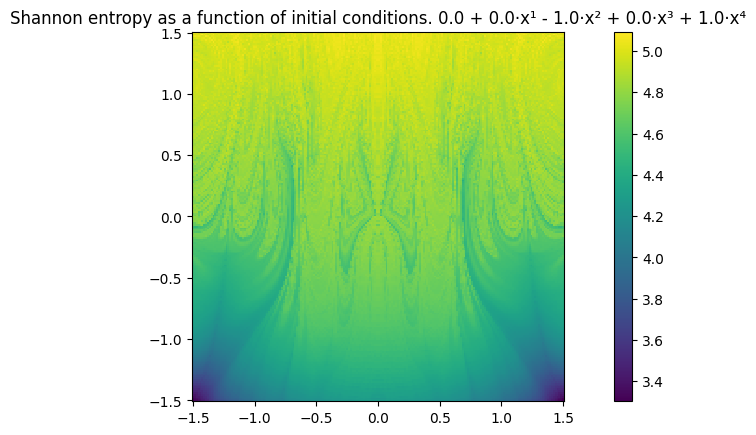

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
#from scipy.stats import skew
from scipy.stats import entropy
import collections
from scipy.special import expit
import time
import math
# Physical constants
k = 20
m = 1
g = 9.81
P = np.polynomial.polynomial.Polynomial([0,-1,1,-1,1]) # potential energy of the spring, as a polynomial of L0-r
Pdot = P.deriv()
L0 = 1
xdot0 = 1
ydot0 = 1

theta0 = -(np.pi) / 4

potentials = [
    np.polynomial.polynomial.Polynomial([0,0,-1,0,1]),
    # np.polynomial.polynomial.Polynomial([0,.9,.9,-.9,1]),
    #          np.polynomial.polynomial.Polynomial([0,.8,.8,-.8,1]),
    #          np.polynomial.polynomial.Polynomial([0,.7,.7,-.7,1]),
    #          np.polynomial.polynomial.Polynomial([0,.6,.6,-.6,1]),
            #  np.polynomial.polynomial.Polynomial([0,.5,.5,-.5,1]),
            #  np.polynomial.polynomial.Polynomial([0,.4,.4,-.4,1]),
            #  np.polynomial.polynomial.Polynomial([0,.3,.3,-.3,1]),
            #  np.polynomial.polynomial.Polynomial([0,.2,.2,-.2,1]),
            #  np.polynomial.polynomial.Polynomial([0,.1,.1,-.1,1]),
            #  np.polynomial.polynomial.Polynomial([0,0,0,0,1]),
            #  np.polynomial.polynomial.Polynomial([0,-.1,-.1,.1,1]),
            #  np.polynomial.polynomial.Polynomial([0,-.2,-.2,.2,1]),
            #  np.polynomial.polynomial.Polynomial([0,-.3,-.3,.3,1]),
            #  np.polynomial.polynomial.Polynomial([0,-.4,-.4,.4,1]),
            #  np.polynomial.polynomial.Polynomial([0,-.5,-.5,.5,1]),
            #  np.polynomial.polynomial.Polynomial([0,-.6,-.6,.6,1]),
            #  np.polynomial.polynomial.Polynomial([0,-.7,-.7,.7,1]),
            #  np.polynomial.polynomial.Polynomial([0,-.8,-.8,.8,1]),
            #  np.polynomial.polynomial.Polynomial([0,-.9,-.9,.9,1]),
            #  np.polynomial.polynomial.Polynomial([0,-1,-1,1,1]),
              #np.polynomial.polynomial.Polynomial([0,0,0,0,1]),
              #np.polynomial.polynomial.Polynomial([0,0,0,0,1]),
              #np.polynomial.polynomial.Polynomial([0,0,0,0,1]),
              ]

def newderiv(n,t,L0,Pdot,m): #just going to try to imitate their form for our new eqautions and see if it works
  theta, ptheta, L, pL = n
  thetadot = ptheta/(m*L*L)
  pthetadot = -m*g*L*np.sin(theta)

  Ldot = pL/m
  pLdot = ptheta*ptheta/(m*L*L*L) + Pdot(L0-L)+ m*g*np.cos(theta)

  return thetadot,pthetadot,Ldot,pLdot

def ham(n): #hamiltonian
  theta, ptheta, L, pL = n
  return 1/(2*m)*(pL**2)+1/(2*m)*L**(-2)*ptheta**(2)+P(L0-L)-m*g*np.cos(theta)
def find_shannon(y0, L0, Pdot):
    # what this does right now is get the list of angles it goes through, rounds
    # them to two decimal places, then uses that to calculate the "probability"
    # of each angle, and takes the entropy of the distribution.
    # Maximum time, time point spacings and the time grid (all in s).
    
    tmax = 5 
    dt = 0.01
    t = np.arange(0, tmax+dt, dt)

    # Do the numerical integration of the equations of motion
    y = odeint(newderiv, y0, t, args=(L0, Pdot, m))

    y[:,0]=np.mod(y[:,0],2*np.pi)
    ### uncomment the rounding for dimensions you actually use, comment it out if it's not in use to improve spead
    y[:,0] = np.round(y[:,0],decimals=0) # theta
    y[:,1] = np.round(y[:,1],decimals=1) # pTheta (angular momentum)
    y[:,2] = np.round(y[:,2],decimals=0) # L (length)
    y[:,3] = np.round(y[:,3],decimals=1) # pL (radial momentum)
    bases = collections.Counter(tuple(i) for i in y[:,0:4:1]) #  For tuples including multiple dimensions
    # bases = collections.Counter(y[:,3])
    distribution = [x/sum(bases.values()) for x in bases.values()]
    return entropy(distribution)

min_entropy = 1000

# def perm_entropy(y0, L0, Pdot, mass=1, embed_dim=4, tau=1):
#     tmax = 20
#     dt = 0.01
#     t = np.arange(0, tmax+dt, dt)

#     y = odeint(newderiv, y0, t, args=(L0, Pdot, mass))  
#     theta = y[:,0]
#     # theta = [round(num, 1) for num in theta]


#     patterns = collections.Counter()

#     for i in range(len(theta) - (embed_dim - 1) * tau):
#         window = theta[i:i + embed_dim * tau:tau]
#         pattern = tuple(np.argsort(window))
#         patterns[pattern] += 1
#     total = sum(patterns.values())
#     probs = [v / total for v in patterns.values()]
#     H = entropy(probs)

#     return H / np.log(math.factorial(embed_dim))

def gradient_plot(initial_conditions, xmin, xmax, ymin, ymax, dots,Pdot):
    global min_entropy
    xcords = np.linspace(xmin,xmax,dots)
    ycords = np.linspace(ymin,ymax,dots)
    colors = np.zeros((dots, dots))

    progress = display('Beginning Plot',display_id=True)

    for x in range(dots):
        for y in range(dots):
            y0 = initial_conditions(xcords[x], ycords[y])
            # debugtime = time.time_ns()
            colors[y,x] = find_shannon(y0, L0, Pdot)
            # if colors[y,x]<min_entropy:
            #     min_entropy = colors[y,x]
            #     print(xcords[x],ycords[y])
            # print(time.time_ns()-debugtime)
            # colors[y,x] = ham(y0)%2 # uncomment this line to display hamiltonian instead, increase the number after the % to increase the space between curves

        progress.update('(' + str(x) + '/' + str(dots) + ')')

    fig1, ax1 = plt.subplots()
    plt.title(str('Shannon entropy as a function of initial conditions. k = ' + str(P)))

    # colors = expit(colors - 10)
    X, Y = np.meshgrid(xcords, ycords)
    plt.pcolormesh(X, Y, colors)

    progress.update('plot complete')


xarray = []
yarray = []


def vary_angle(x0,y0):
    """convert x,y coordinate on plot into initial conditions array"""
    theta0 = np.arctan2(x0, -y0)
    L0 = np.sqrt(x0**2 + y0**2)
    return [theta0, 0, L0, 0]

#Unfinished
def vary_angle_with_kick(x0,y0):
    theta0 = np.arctan2(x0, -y0)
    #theta0 = -(np.pi) / 4
    L0 = np.sqrt(x0**2 + y0**2)
    #L0 = 1.2
    pL0 = -ydot0
    ptheta0 = xdot0*y0
    return [theta0, ptheta0, L0, pL0]

#Our main function for creating the gradient plot

# gradient_plot(vary_angle, -2+.00001, 2+.00001, -2+.00001, 2+.00001, 301)
# plt.show()
# plt.close()


# ----------- BATCH RUN --------------

for i, P in enumerate(potentials):
    print("Running potential", i)
    
    Pdot = P.deriv()

    gradient_plot(vary_angle, -1.5, 1.5, -1.5, 1.5, 50, Pdot)
    plt.colorbar(pad=.1)
    plt.title(f"Shannon entropy as a function of initial conditions. {P}")
    plt.show()